In [3]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report
import matplotlib.pyplot as plt
import numpy as np
import os

In [5]:
# 2. Carga del Dataset y división de datos
digits = load_digits()
X = digits.data
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Dataset cargado y dividido correctamente.")
print(f"   Entrenamiento: {X_train.shape[0]} muestras | Prueba: {X_test.shape[0]} muestras\n")

✅ Dataset cargado y dividido correctamente.
   Entrenamiento: 1437 muestras | Prueba: 360 muestras



In [6]:
# 3. Entrenamiento de los 3 modelos
print("🔹 Entrenando modelos...")

# KNN (k=5)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# SVM (kernel RBF)
svm = SVC(kernel='rbf', probability=False, random_state=42)
svm.fit(X_train, y_train)

# Random Forest (100 estimadores)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("✅ Modelos entrenados correctamente.\n")

🔹 Entrenando modelos...
✅ Modelos entrenados correctamente.



In [7]:
# 4. Evaluación de modelos
print("📊 Resultados de Exactitud (Accuracy) en conjunto de prueba:")
print(f"   KNN:         {accuracy_score(y_test, knn.predict(X_test)):.4f}")
print(f"   SVM (RBF):   {accuracy_score(y_test, svm.predict(X_test)):.4f}")
print(f"   Random Forest: {accuracy_score(y_test, rf.predict(X_test)):.4f}\n")

📊 Resultados de Exactitud (Accuracy) en conjunto de prueba:
   KNN:         0.9861
   SVM (RBF):   0.9861
   Random Forest: 0.9722



In [8]:
# 5. Creación de 3 imágenes propias (Matrices 8x8)
# INSTRUCCIÓN: Modifica los valores (0-16) para dibujar tus propios dígitos.
# 0 = negro, 16 = blanco. Puedes usar valores intermedios para bordes suaves.

mis_digitos = {
    "Dígito_1": np.array([
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 5, 8, 0, 0, 0],
        [0, 0, 10, 14, 12, 0, 0, 0],
        [0, 0, 0, 8, 8, 0, 0, 0],
        [0, 0, 0, 8, 8, 0, 0, 0],
        [0, 0, 0, 8, 8, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0]
    ]),
    "Dígito_2": np.array([
        [0, 0, 4, 8, 8, 4, 0, 0],
        [0, 0, 8, 12, 14, 8, 0, 0],
        [0, 0, 0, 0, 8, 10, 0, 0],
        [0, 0, 0, 4, 12, 4, 0, 0],
        [0, 0, 8, 10, 0, 0, 0, 0],
        [0, 0, 12, 4, 0, 0, 0, 0],
        [0, 0, 12, 12, 12, 12, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0]
    ]),
    "Dígito_3": np.array([
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 4, 10, 8, 0, 0, 0],
        [0, 0, 8, 0, 10, 0, 0, 0],
        [0, 0, 0, 4, 12, 4, 0, 0],
        [0, 0, 0, 0, 12, 8, 0, 0],
        [0, 0, 8, 0, 10, 0, 0, 0],
        [0, 0, 4, 10, 8, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0]
    ])
}

# Aplanar matrices para predicción (formato 1x64)
datos_personalizados = {nombre: img.reshape(1, -1) for nombre, img in mis_digitos.items()}

🖼️ Predicciones sobre imágenes creadas manualmente:
   Dígito_1 -> KNN:1, SVM:1, RF:1
   Dígito_2 -> KNN:2, SVM:2, RF:7
   Dígito_3 -> KNN:1, SVM:4, RF:1


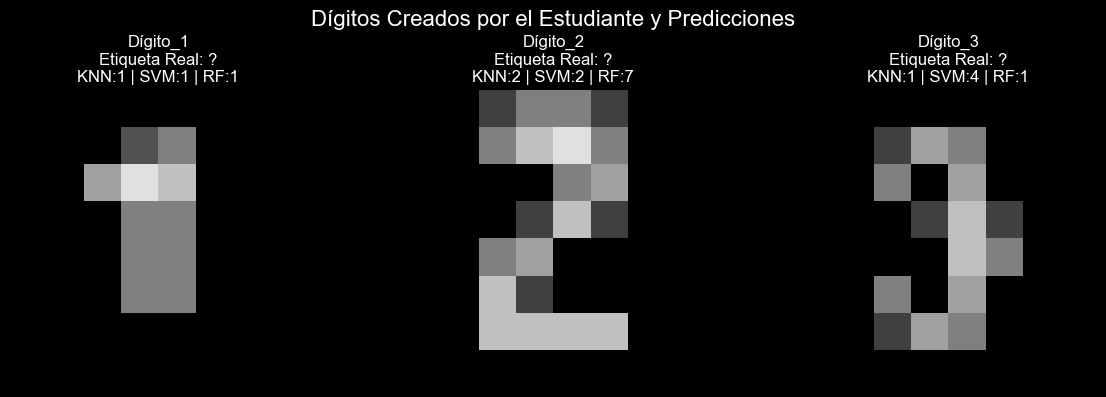

In [9]:
# 6. Predicción y Visualización
print("🖼️ Predicciones sobre imágenes creadas manualmente:")
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle('Dígitos Creados por el Estudiante y Predicciones', fontsize=16)

for i, (nombre, matriz) in enumerate(mis_digitos.items()):
    X_pred = datos_personalizados[nombre]

    pred_knn = knn.predict(X_pred)[0]
    pred_svm = svm.predict(X_pred)[0]
    pred_rf  = rf.predict(X_pred)[0]

    # Mostrar imagen
    axes[i].imshow(matriz, cmap='gray', vmin=0, vmax=16)
    axes[i].set_title(f"{nombre}\nEtiqueta Real: ?\nKNN:{pred_knn} | SVM:{pred_svm} | RF:{pred_rf}")
    axes[i].axis('off')
    print(f"   {nombre} -> KNN:{pred_knn}, SVM:{pred_svm}, RF:{pred_rf}")

plt.tight_layout()
plt.show()

In [10]:
# Guardar las imágenes para el entregable
for i, nombre in enumerate(mis_digitos.keys()):
    plt.figure(figsize=(2,2))
    plt.imshow(mis_digitos[nombre], cmap='gray', vmin=0, vmax=16)
    plt.axis('off')
    plt.savefig(f"img/{nombre}_8x8.png", dpi=100, bbox_inches='tight')
    plt.close()